In [3]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

def preprocess_crime_data(file_path):
    """
    Preprocess crime data for spatial-temporal point process modeling.
    Only drops rows where lat, lon, or time is null.
    Preserves the original incident date in the final dataframe.
    
    Parameters:
    file_path (str): Path to the CSV file containing crime data
    
    Returns:
    pandas.DataFrame: Processed dataframe with normalized features
    """
    print(f"Loading data from {file_path}...")
    
    # Load data
    df = pd.read_csv(file_path)
    
    print(f"Original data shape: {df.shape}")
    
    # Make a copy to avoid modifying the original
    processed_df = df.copy()
    
    # 2. Time normalization
    print("\nNormalizing time data...")
    
    # Extract hours, minutes, seconds and convert to fraction of day
    def time_to_fraction(time_str):
        try:
            if pd.isna(time_str):
                return np.nan
                
            # Handle various time formats
            if ':' in str(time_str):
                parts = str(time_str).split(':')
                if len(parts) == 3:  # HH:MM:SS
                    hours, minutes, seconds = map(int, parts)
                elif len(parts) == 2:  # HH:MM
                    hours, minutes = map(int, parts)
                    seconds = 0
                else:
                    return np.nan
            else:
                # Handle military time format
                try:
                    time_int = int(time_str)
                    hours = time_int // 100
                    minutes = time_int % 100
                    seconds = 0
                except:
                    return np.nan
            
            return (hours * 3600 + minutes * 60 + seconds) / (24 * 3600)
        except:
            return np.nan
    
    processed_df['time_fraction'] = processed_df['OccurredFromTime'].apply(time_to_fraction)
    
    # 3. Spatial normalization - Only drop if lat, lon, OR time is missing (essential for analysis)
    print("\nNormalizing spatial coordinates...")
    
    # Identify rows with any missing spatial or time data
    missing_data_mask = (
        processed_df['Latitude'].isna() | 
        processed_df['Longitude'].isna() | 
        processed_df['time_fraction'].isna()
    )
    
    # Count missing values before dropping
    print(f"Rows with missing latitude: {processed_df['Latitude'].isna().sum()}")
    print(f"Rows with missing longitude: {processed_df['Longitude'].isna().sum()}")
    print(f"Rows with missing time: {processed_df['time_fraction'].isna().sum()}")
    print(f"Total rows to be removed due to missing essential data: {missing_data_mask.sum()}")
    
    # Drop rows with missing essential data
    processed_df = processed_df[~missing_data_mask]
    print(f"Data shape after dropping rows with missing essential data: {processed_df.shape}")
    
    # Normalize time to have SD=1
    mean_time = processed_df['time_fraction'].mean()
    std_time = processed_df['time_fraction'].std()
    processed_df['time_normalized'] = (processed_df['time_fraction'] - mean_time) / std_time
    
    # Normalize coordinates to [0,1] range and then standardize
    lat_min = processed_df['Latitude'].min()
    lat_max = processed_df['Latitude'].max()
    processed_df['lat_01'] = (processed_df['Latitude'] - lat_min) / (lat_max - lat_min)
    
    lon_min = processed_df['Longitude'].min()
    lon_max = processed_df['Longitude'].max()
    processed_df['lon_01'] = (processed_df['Longitude'] - lon_min) / (lon_max - lon_min)
    
    # Then standardize to have SD=1
    lat_mean = processed_df['lat_01'].mean()
    lat_std = processed_df['lat_01'].std()
    processed_df['lat_normalized'] = (processed_df['lat_01'] - lat_mean) / lat_std
    
    lon_mean = processed_df['lon_01'].mean()
    lon_std = processed_df['lon_01'].std()
    processed_df['lon_normalized'] = (processed_df['lon_01'] - lon_mean) / lon_std
    
    # 4. Crime type categorization
    print("\nCategorizing crime types...")
    NIBRS_CATEGORIES = {
        'ASSAULT': ['13A', '13B', '13C'],
        'THEFT': ['23A', '23B', '23C', '23D', '23E', '23F', '23G', '23H'], 
        'SEX CRIMES': ['36A', '36B', '11A', '11B', '11C', '11D'], 
        'HOMICIDE': ['09A', '09B', '09C'], 
        'GROUP B': ['90A', '90F','90B','90C','90D','90E','90H','90H','90I','90J','90Z'],
        'FRAUD': ['26A', '26B', '26C', '26D', '26E'],
        'DRUG OFFENSES': ['35A', '35B'],
        'BURGLARY': ['220']
    }
    
    # Function to map NIBRS code to category
    def map_to_category(nibrs_code):
        """
        Map NIBRS code to simplified crime types.
        """
        # Convert to string and strip whitespace for consistent comparison
        nibrs_code = str(nibrs_code).strip()
        
        if nibrs_code in NIBRS_CATEGORIES['ASSAULT'] or nibrs_code in NIBRS_CATEGORIES['HOMICIDE']:
            return "VIOLENT CRIME"
        elif nibrs_code in NIBRS_CATEGORIES['SEX CRIMES']:
            return "SEX CRIMES"
        elif nibrs_code in NIBRS_CATEGORIES['THEFT']:
            return "THEFT"
        else:
            return 'OTHER'
    
    # Apply categorization
    processed_df['crime_category'] = processed_df['NIBRS'].apply(map_to_category)
    
    # Display distribution before filtering
    print("\nCrime category distribution before filtering:")
    print(processed_df['crime_category'].value_counts())
    
    # Filter to include only relevant categories
    before_filter = len(processed_df)
    processed_df = processed_df[processed_df['crime_category'].isin(['VIOLENT CRIME', 'THEFT', 'SEX CRIMES'])]
    after_filter = len(processed_df)
    print(f"Rows removed due to category filtering: {before_filter - after_filter}")
    
    # Create final dataframe with relevant columns - preserving the original IncidentDate
    final_cols = ['IncidentDate', 'time_normalized', 'lat_normalized', 'lon_normalized', 
                  'crime_category', 'NIBRS', 'Latitude', 'Longitude', 'IncidentNum']
    
    final_df = processed_df[final_cols]
    
    # Print summary statistics
    print(f"\nFinal processed data shape: {final_df.shape}")
    print("\nCrime category distribution in final dataset:")
    print(final_df['crime_category'].value_counts())
    
    # Generate preview plots
    print("\nGenerating preview plots...")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Crime type distribution
    sns.countplot(y=final_df['crime_category'], ax=axes[0])
    axes[0].set_title('Crime Category Distribution')
    
    # Spatial distribution (scatter plot of a sample)
    sample_size = min(5000, len(final_df))
    sample = final_df.sample(sample_size)
    scatter = axes[1].scatter(
        sample['Longitude'], 
        sample['Latitude'],
        c=sample['crime_category'].map({'VIOLENT CRIME': 'red', 'THEFT': 'blue', 'SEX CRIMES': 'green'}),
        alpha=0.5, 
        s=10
    )
    axes[1].set_title('Spatial Distribution (Sample)')
    axes[1].legend(handles=scatter.legend_elements()[0], labels=['VIOLENT CRIME', 'THEFT', 'SEX CRIMES'])
    
    plt.tight_layout()
    plt.show()
    
    return final_df

Loading data from cleaned_2021-jan2025.csv...


/var/folders/d9/f8_tyf717wv682nmfcb5jclh0000gn/T/ipykernel_3014/2355593179.py:22: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Original data shape: (228776, 22)

Normalizing time data...

Normalizing spatial coordinates...
Rows with missing latitude: 2665
Rows with missing longitude: 2665
Rows with missing time: 1609
Total rows to be removed due to missing essential data: 2665
Data shape after dropping rows with missing essential data: (226111, 23)

Categorizing crime types...

Crime category distribution before filtering:
crime_category
OTHER            151746
THEFT             47502
VIOLENT CRIME     25747
SEX CRIMES         1116
Name: count, dtype: int64
Rows removed due to category filtering: 151746

Final processed data shape: (74365, 9)

Crime category distribution in final dataset:
crime_category
THEFT            47502
VIOLENT CRIME    25747
SEX CRIMES        1116
Name: count, dtype: int64

Generating preview plots...


/opt/anaconda3/envs/hw510.2/lib/python3.11/site-packages/matplotlib/collections.py:1080: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


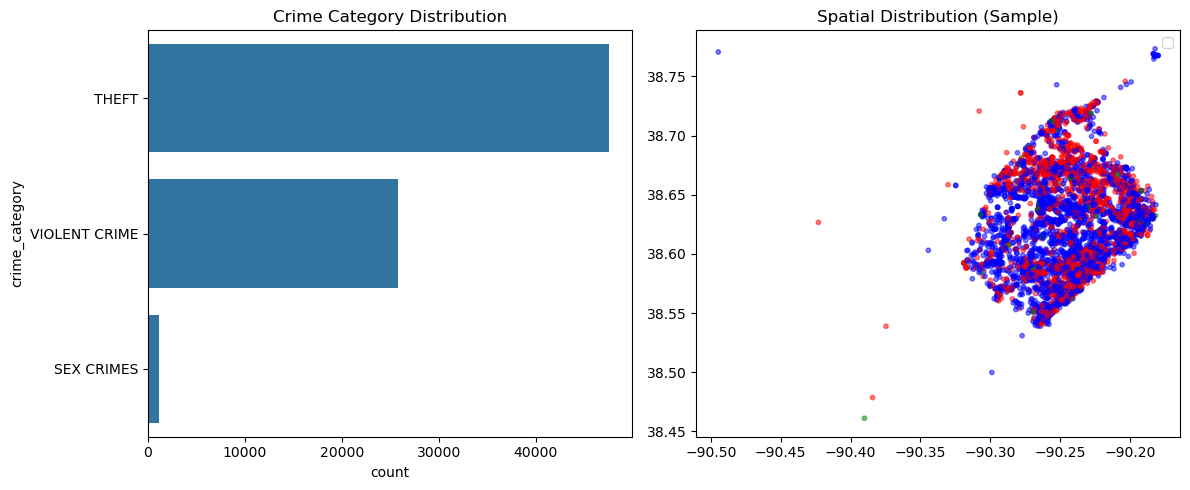

In [2]:
# Function call
file_path = "cleaned_2021-jan2025.csv"
df = preprocess_crime_data(file_path)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf
import seaborn as sns

def analyze_crime_seasonality(df, max_lag=365):
    """
    Analyze seasonality in crime data using autocorrelation functions (ACF).
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Preprocessed crime dataframe from preprocess_crime_data function
    max_lag : int, optional (default=365)
        Maximum number of lags for autocorrelation analysis
        
    Returns:
    --------
    dict
        Dictionary containing time series for each crime category
    
    Notes:
    ------
    In the ACF plot, significant spikes at regular intervals indicate seasonality:
    - A spike at lag 7 suggests weekly seasonality
    - A spike at lag 14 suggests biweekly seasonality
    - A spike at lags 28-31 suggests monthly seasonality
    - A spike at lag 90-92 suggests quarterly seasonality
    - A spike at lag 365 suggests yearly seasonality
    
    The blue shaded area in the ACF plot represents the 95% confidence interval.
    Peaks above this area are statistically significant.
    """
    
    # 1. Convert IncidentDate to datetime if needed (minimal safety check)
    if not pd.api.types.is_datetime64_any_dtype(df['IncidentDate']):
        df['IncidentDate'] = pd.to_datetime(df['IncidentDate'], format='mixed')
    
    # 2. Group by date and crime category, count incidents
    daily_counts = df.groupby([df['IncidentDate'].dt.date, 'crime_category']).size().reset_index()
    # Convert date column to datetime for proper merging later
    daily_counts['date'] = pd.to_datetime(daily_counts['date'])
    daily_counts.columns = ['date', 'crime_category', 'count']
    
    # 3. Create time series for each category with complete date range
    start_date = daily_counts['date'].min()
    end_date = daily_counts['date'].max()
    date_range = pd.date_range(start=start_date, end=end_date, freq='D')
    
    # Dictionary to store time series
    time_series = {}
    
    # 4. For each crime category, create a time series 
    categories = sorted(df['crime_category'].unique())
    
    # Create complete time series for each category
    for category in categories:
        # Filter data for this category
        category_data = daily_counts[daily_counts['crime_category'] == category]
        
        # Create complete time series with zeros for missing dates
        ts = pd.DataFrame({'date': date_range})
        ts = ts.merge(category_data[['date', 'count']], on='date', how='left')
        ts['count'] = ts['count'].fillna(0)
        ts.set_index('date', inplace=True)
        
        time_series[category] = ts
    
    # Create subplots for visualization - 2 plots per category
    fig, all_axes = plt.subplots(len(categories), 2, figsize=(15, 4*len(categories)))
    
    # Handle case of single category
    if len(categories) == 1:
        all_axes = np.array([all_axes]).reshape(1, 2)
    
    for i, category in enumerate(categories):
        ts = time_series[category]
        
        # Get axes for this category
        ax_ts = all_axes[i, 0]
        ax_acf = all_axes[i, 1]
            
        # Plot time series (last year if available, or all data if less than a year)
        days_to_plot = min(365, len(ts))
        ax_ts.plot(ts.index[-days_to_plot:], ts['count'][-days_to_plot:], 'b-')
        ax_ts.set_title(f'Daily Crime Count - {category}')
        ax_ts.set_ylabel('Count')
        ax_ts.set_xlabel('Date')
        plt.setp(ax_ts.xaxis.get_majorticklabels(), rotation=45)
        
        # Add rolling average
        window = 7  # 7-day moving average
        if len(ts) >= window:
            rolling_avg = ts['count'].rolling(window=window).mean()
            ax_ts.plot(ts.index[-days_to_plot:], rolling_avg[-days_to_plot:], 'r-', 
                     alpha=0.7, label=f'{window}-day moving avg')
            ax_ts.legend()
        
        # Plot ACF
        sm.graphics.tsa.plot_acf(ts['count'], lags=max_lag, ax=ax_acf, alpha=0.05)
        ax_acf.set_title(f'Autocorrelation Function - {category}')
        
        # Calculate confidence interval manually for annotations
        n = len(ts)
        conf_level = 1.96 / np.sqrt(n)  # 95% confidence interval
        
        # Add markers for common seasonal periods
        common_periods = [7, 14, 30, 90, 365]  # weekly, biweekly, monthly, quarterly, yearly
        acf_values = acf(ts['count'], nlags=max_lag, fft=True)
        
        for period in common_periods:
            if period <= max_lag:
                ax_acf.axvline(x=period, color='r', linestyle='--', alpha=0.3)
                if abs(acf_values[period]) > conf_level:  # If significant
                    ax_acf.annotate(f'{period}d', xy=(period, acf_values[period]),
                                  xytext=(0, 10), textcoords='offset points',
                                  ha='center', color='r', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Print insights about detected seasonality
    print("\nSeasonality Insights:")
    for category in categories:
        ts_data = time_series[category]['count']
        
        # Calculate ACF and confidence interval
        acf_values = acf(ts_data, nlags=max_lag, fft=True)
        n = len(ts_data)
        conf_level = 1.96 / np.sqrt(n)  # 95% confidence interval
        
        # Find significant autocorrelations
        significant_lags = [lag for lag in range(1, len(acf_values)) 
                           if abs(acf_values[lag]) > conf_level]
        
        # Check for common seasonal patterns
        weekly = 7 in significant_lags
        biweekly = 14 in significant_lags
        monthly = any(lag in significant_lags for lag in range(28, 32))
        quarterly = any(lag in significant_lags for lag in range(90, 93))
        yearly = any(lag in significant_lags for lag in range(364, 367))
        
        print(f"\n{category}:")
        if significant_lags:
            print(f"- Significant autocorrelation at lags: {significant_lags}")
            
            seasonal_patterns = []
            if weekly:
                seasonal_patterns.append("weekly (7-day)")
            if biweekly:
                seasonal_patterns.append("biweekly (14-day)")
            if monthly:
                seasonal_patterns.append("monthly (28-31 day)")
            if quarterly:
                seasonal_patterns.append("quarterly (90-92 day)")
            if yearly:
                seasonal_patterns.append("yearly (365-day)")
                
            if seasonal_patterns:
                print(f"- Detected seasonality patterns: {', '.join(seasonal_patterns)}")
                
            # Filter out the common ones we already reported
            common_lags = [7, 14] + list(range(28, 32)) + list(range(90, 93)) + list(range(364, 367))
            other_significant = [lag for lag in significant_lags if lag not in common_lags]
            
            if other_significant:
                print(f"- Other potentially important cycles at lag(s): {other_significant}")
        else:
            print("- No significant seasonality detected within the specified lag range")
    
    return time_series

analyze_crime_seasonality(df, max_lag=400)

ValueError: You are trying to merge on datetime64[ns] and object columns. If you wish to proceed you should use pd.concat

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KernelDensity
import contextily as ctx
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as PathEffects
from scipy.stats import gaussian_kde

def create_spatial_kde(processed_data, bandwidth=0.01):
    """
    Create spatial KDEs for each crime type and visualize on map.
    
    Parameters:
    processed_data (pandas.DataFrame): Processed crime data
    bandwidth (float): Bandwidth parameter for KDE
    
    Returns:
    dict: Dictionary of KDE models by crime type
    """
    print("Creating spatial KDEs for each crime category...")
    
    # Get unique crime categories
    crime_types = processed_data['crime_category'].unique()
    print(f"Crime categories: {crime_types}")
    
    # Dictionary to store KDE models for each crime type
    kde_models = {}
    
    # Create figure for visualization
    fig, axes = plt.subplots(len(crime_types), 2, figsize=(18, 6*len(crime_types)))
    if len(crime_types) == 1:
        axes = [axes]  # Handle case with only one crime type
    
    # St. Louis approximate bounding box
    # These coordinates can be adjusted for better focus on the city
    min_lat, max_lat = 38.53, 38.77
    min_lon, max_lon = -90.32, -90.17
    
    # Create meshgrid for KDE evaluation
    grid_size = 100
    lon_grid = np.linspace(min_lon, max_lon, grid_size)
    lat_grid = np.linspace(min_lat, max_lat, grid_size)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
    
    # Color maps for different crime types
    color_maps = {
        'VIOLENT CRIME': 'Reds',
        'THEFT': 'Blues',
        'SEX CRIMES': 'Purples'
    }
    
    for i, crime_type in enumerate(crime_types):
        print(f"\nProcessing {crime_type}...")
        
        # Filter data for current crime type
        crime_data = processed_data[processed_data['crime_category'] == crime_type]
        print(f"Number of {crime_type} incidents: {len(crime_data)}")
        
        # Extract coordinates
        points = crime_data[['Longitude', 'Latitude']].values
        
        # Fit KDE model using scikit-learn
        kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian')
        kde.fit(points)
        
        # Store model
        kde_models[crime_type] = kde
        
        # Evaluate KDE on grid
        positions = np.vstack([lon_mesh.ravel(), lat_mesh.ravel()]).T
        density = np.exp(kde.score_samples(positions))
        density = density.reshape(lon_mesh.shape)
        
        # Plot point distribution
        axes[i, 0].scatter(
            crime_data['Longitude'], 
            crime_data['Latitude'], 
            s=5, 
            alpha=0.5,
            c='k'
        )
        axes[i, 0].set_title(f'{crime_type} Incidents')
        axes[i, 0].set_xlabel('Longitude')
        axes[i, 0].set_ylabel('Latitude')
        axes[i, 0].set_xlim(min_lon, max_lon)
        axes[i, 0].set_ylim(min_lat, max_lat)
        
        # Add basemap
        try:
            ctx.add_basemap(
                axes[i, 0], 
                crs='EPSG:4326',  # WGS84 - standard latitude/longitude
                source=ctx.providers.CartoDB.Positron
            )
        except Exception as e:
            print(f"Could not add basemap: {e}")
            print("Continuing without basemap...")
        
        # Plot KDE with basemap
        im = axes[i, 1].pcolormesh(
            lon_mesh, 
            lat_mesh, 
            density, 
            cmap=color_maps.get(crime_type, 'viridis'),
            alpha=0.7,
            shading='auto'
        )
        axes[i, 1].set_title(f'{crime_type} Kernel Density Estimate')
        axes[i, 1].set_xlabel('Longitude')
        axes[i, 1].set_ylabel('Latitude')
        axes[i, 1].set_xlim(min_lon, max_lon)
        axes[i, 1].set_ylim(min_lat, max_lat)
        
        # Add colorbar
        plt.colorbar(im, ax=axes[i, 1], label='Density')
        
        # Add basemap
        try:
            ctx.add_basemap(
                axes[i, 1], 
                crs='EPSG:4326', 
                source=ctx.providers.CartoDB.Positron
            )
        except Exception as e:
            print(f"Could not add basemap: {e}")
            print("Continuing without basemap...")
            
        # Calculate KDE diagnostics
        print(f"KDE max density: {density.max():.4f}")
        print(f"KDE min density: {density.min():.4f}")
        print(f"KDE mean density: {density.mean():.4f}")
        
        # Calculate hotspots (areas with density > 90th percentile)
        hotspot_threshold = np.percentile(density, 90)
        hotspots = density > hotspot_threshold
        print(f"Number of hotspot cells (>90th percentile): {np.sum(hotspots)}")
    
    plt.tight_layout()
    plt.show()
    
    # Create a combined heatmap for all crime types
    print("\nCreating combined heatmap for all crime types...")
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Use a combined dataset for all points
    all_points = processed_data[['Longitude', 'Latitude']].values
    
    # Use scipy's gaussian_kde which can be more efficient for large datasets
    kernel = gaussian_kde(all_points.T, bw_method=bandwidth)
    
    # Evaluate the KDE on our grid
    positions = np.vstack([lon_mesh.ravel(), lat_mesh.ravel()])
    all_density = kernel(positions).reshape(lon_mesh.shape)
    
    # Plot the combined KDE
    im = ax.pcolormesh(
        lon_mesh, 
        lat_mesh, 
        all_density, 
        cmap='hot_r',
        alpha=0.7,
        shading='auto'
    )
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, label='Density')
    
    # Customize plot
    ax.set_title('Combined Crime Intensity - St. Louis', fontsize=16)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    
    # Add basemap
    try:
        ctx.add_basemap(
            ax, 
            crs='EPSG:4326', 
            source=ctx.providers.CartoDB.Positron
        )
    except Exception as e:
        print(f"Could not add basemap: {e}")
        print("Continuing without basemap...")
    
    # Add city label
    txt = ax.text(
        -90.25, 38.75, 'St. Louis', 
        fontsize=18, 
        ha='center', 
        color='white'
    )
    txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='black')])
    
    plt.tight_layout()
    plt.show()
    
    # Return KDE models for later use in the full intensity model
    return kde_models

def evaluate_kde_performance(processed_data, kde_models, bandwidth=0.01):
    """
    Evaluate KDE performance using cross-validation.
    
    Parameters:
    processed_data (pandas.DataFrame): Processed crime data
    kde_models (dict): Dictionary of KDE models by crime type
    bandwidth (float): Bandwidth parameter for KDE
    """
    print("\nEvaluating KDE performance...")
    
    from sklearn.model_selection import KFold
    from sklearn.metrics import log_loss
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    results = {}
    
    for crime_type, kde in kde_models.items():
        print(f"\nEvaluating KDE for {crime_type}...")
        
        # Filter data for current crime type
        crime_data = processed_data[processed_data['crime_category'] == crime_type]
        
        if len(crime_data) < 100:
            print(f"Too few samples for {crime_type}, skipping cross-validation.")
            continue
            
        # Extract coordinates
        points = crime_data[['Longitude', 'Latitude']].values
        
        # Scores for each fold
        cv_scores = []
        
        for train_idx, test_idx in kf.split(points):
            # Train data
            train_points = points[train_idx]
            
            # Test data
            test_points = points[test_idx]
            
            # Fit KDE on training data
            train_kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian')
            train_kde.fit(train_points)
            
            # Score on test data (log-likelihood)
            log_likelihood = train_kde.score_samples(test_points)
            
            # Convert to probability (exp of log-likelihood)
            prob = np.exp(log_likelihood)
            
            # Store average log likelihood
            cv_scores.append(np.mean(log_likelihood))
        
        # Store results
        results[crime_type] = {
            'mean_log_likelihood': np.mean(cv_scores),
            'std_log_likelihood': np.std(cv_scores)
        }
        
        print(f"Mean Log-Likelihood: {results[crime_type]['mean_log_likelihood']:.4f}")
        print(f"Std Dev Log-Likelihood: {results[crime_type]['std_log_likelihood']:.4f}")
    
    return results

# Usage example:
# kde_models = create_spatial_kde(processed_data)
# kde_evaluation = evaluate_kde_performance(processed_data, kde_models)

Creating spatial KDEs for each crime category...
Crime categories: ['THEFT' 'VIOLENT CRIME' 'SEX CRIMES']

Processing THEFT...
Number of THEFT incidents: 47502
KDE max density: 246.4705
KDE min density: 0.0000
KDE mean density: 27.0887
Number of hotspot cells (>90th percentile): 1000

Processing VIOLENT CRIME...
Number of VIOLENT CRIME incidents: 25747
KDE max density: 238.3541
KDE min density: 0.0000
KDE mean density: 27.0853
Number of hotspot cells (>90th percentile): 1000

Processing SEX CRIMES...
Number of SEX CRIMES incidents: 1116
KDE max density: 221.2826
KDE min density: 0.0000
KDE mean density: 27.0265
Number of hotspot cells (>90th percentile): 1000


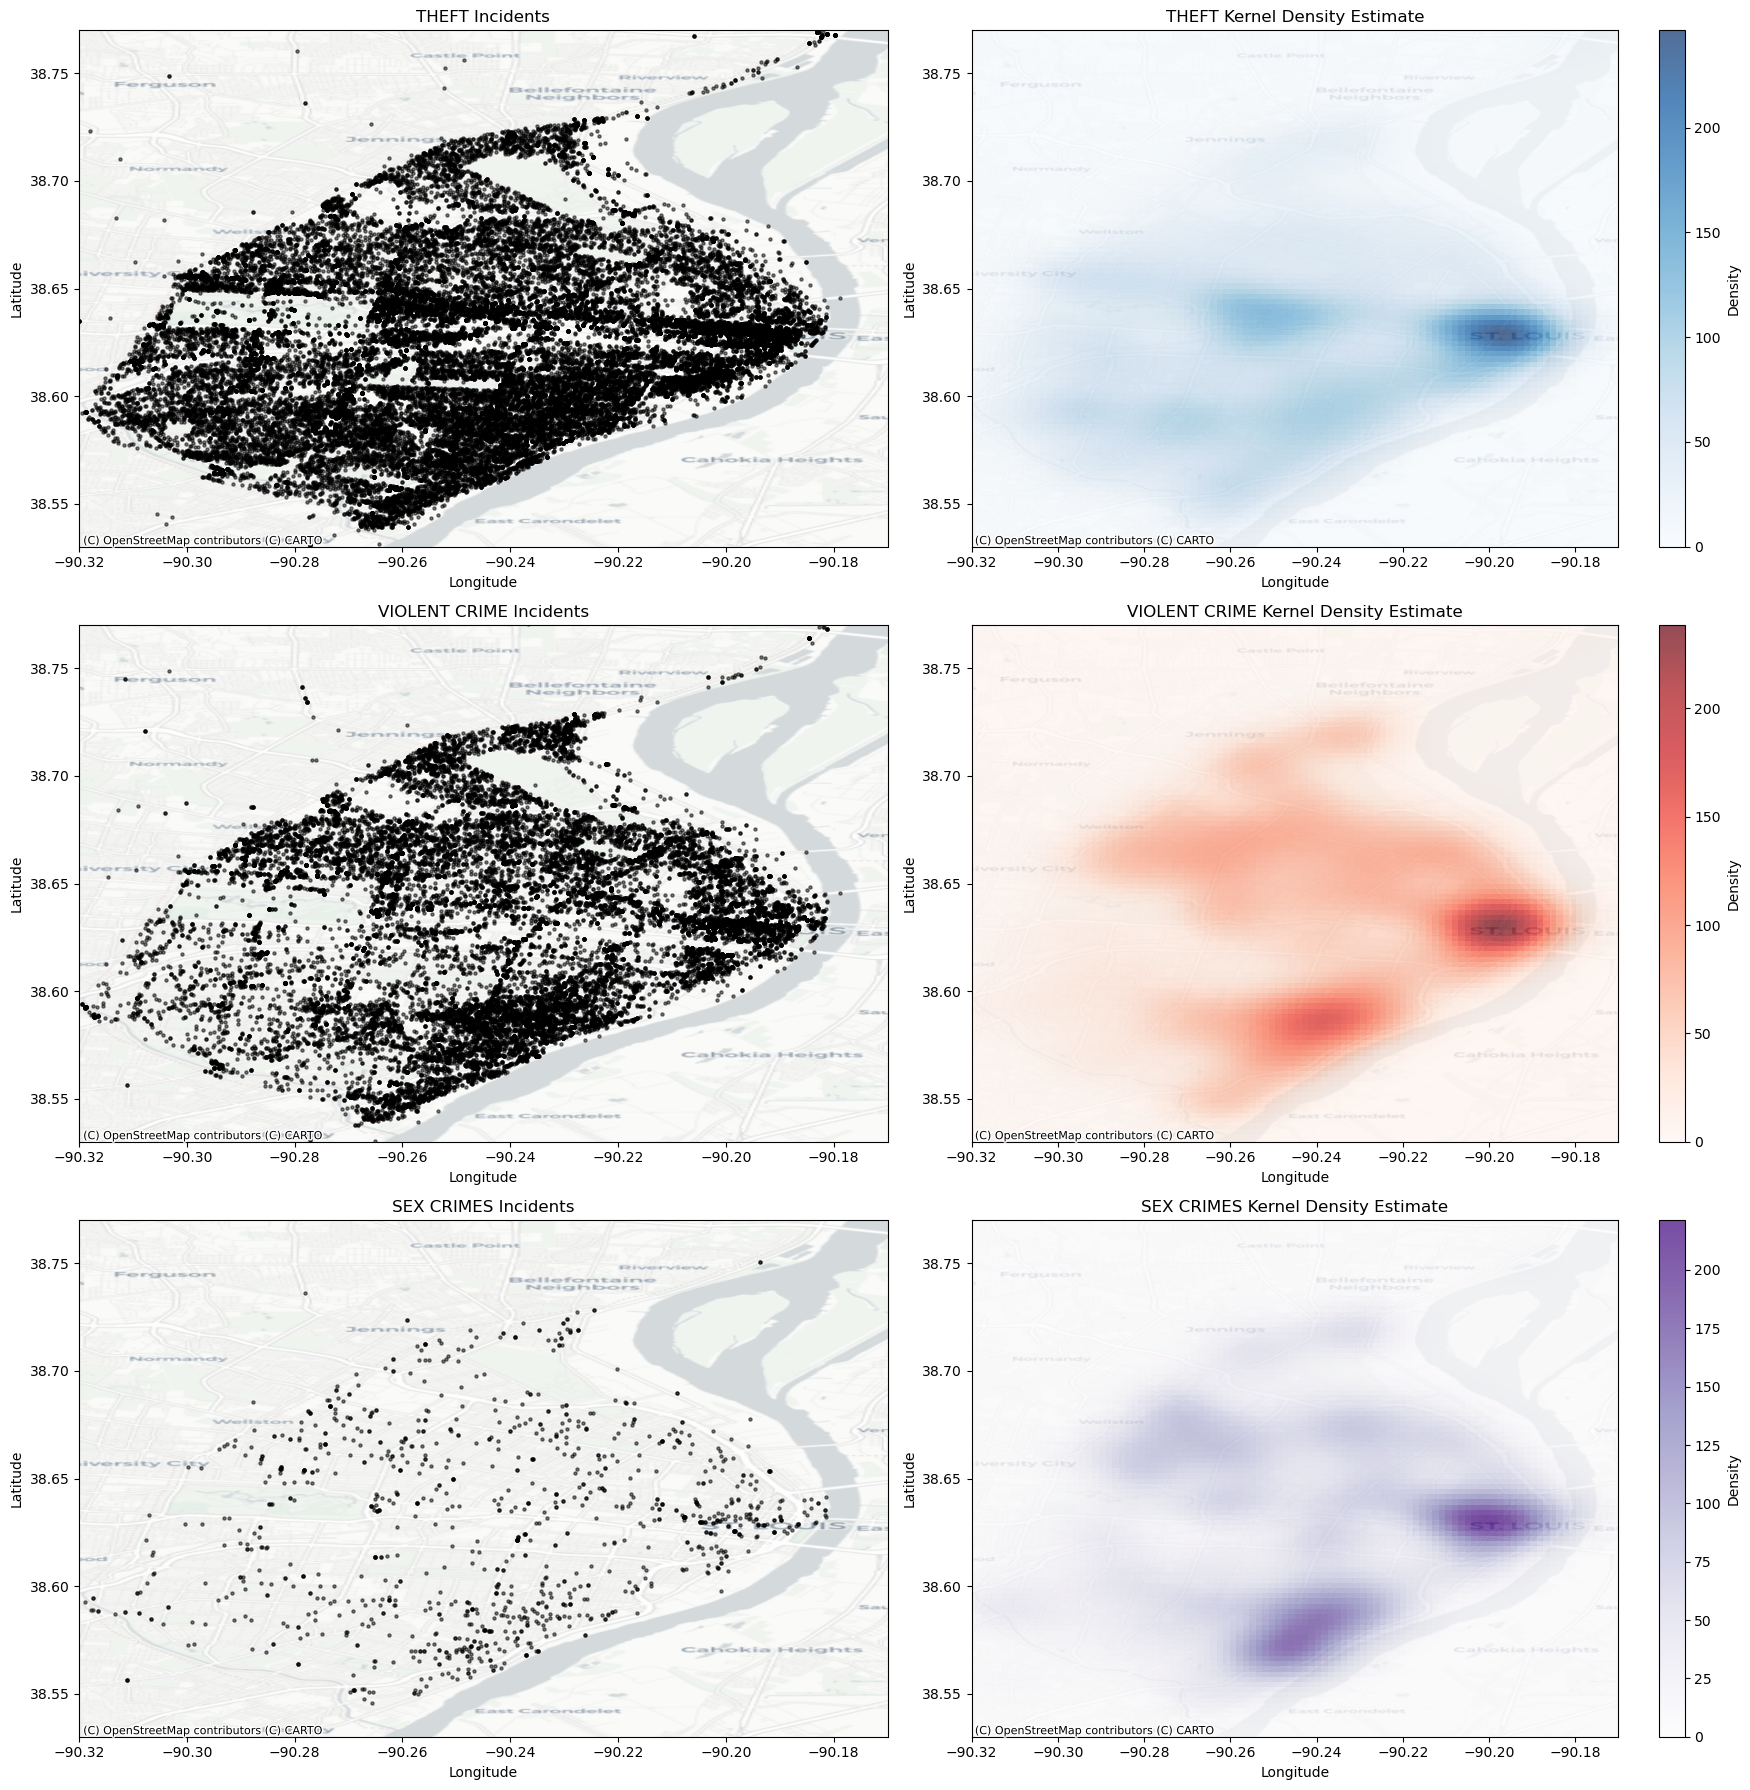


Creating combined heatmap for all crime types...


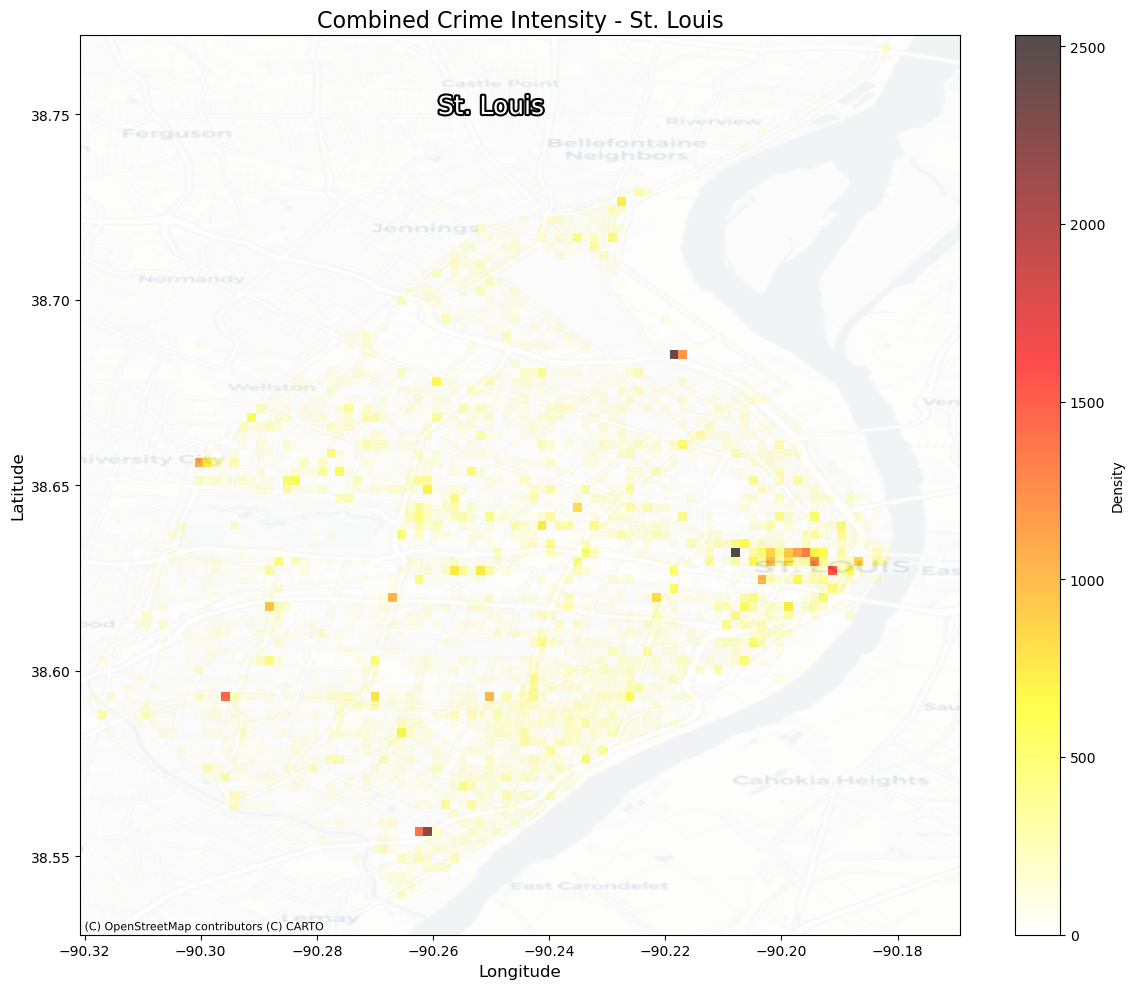


Evaluating KDE performance...

Evaluating KDE for THEFT...
Mean Log-Likelihood: 4.0096
Std Dev Log-Likelihood: 0.2161

Evaluating KDE for VIOLENT CRIME...
Mean Log-Likelihood: 0.7448
Std Dev Log-Likelihood: 6.9422

Evaluating KDE for SEX CRIMES...
Mean Log-Likelihood: 4.1119
Std Dev Log-Likelihood: 0.1473


In [4]:
# Create and visualize KDEs
for bandwidth in [0.0075]:
    kde_models = create_spatial_kde(df, bandwidth=bandwidth)  # Adjust bandwidth as needed
    # Evaluate KDE performance
    kde_evaluation = evaluate_kde_performance(df, kde_models)

In [ ]:
# Import the function
from acf_analysis import analyze_crime_data_acf

# Or if you have the preprocessed DataFrame already in memory:
ts_daily = analyze_crime_data_acf(preprocessed_data=df)

In [6]:
# This will take forever to run with s = 365
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from itertools import product
import warnings
warnings.filterwarnings('ignore')

def create_and_optimize_sarima(preprocessed_data, output_file=None):
    """
    Create a SARIMA model with 24-hour binning and perform hyperparameter optimization.
    
    Parameters:
    preprocessed_data (pandas.DataFrame): The preprocessed crime data
    output_file (str, optional): Path to save model results
    
    Returns:
    tuple: Best model, parameters, and time series data
    """
    # 1. Convert IncidentDate to datetime if it's not already
    print("Converting date format if needed...")
    try:
        # Try to determine if it's already datetime
        if not pd.api.types.is_datetime64_any_dtype(preprocessed_data['IncidentDate']):
            preprocessed_data['IncidentDate'] = pd.to_datetime(
                preprocessed_data['IncidentDate'], errors='coerce'
            )
    except Exception as e:
        print(f"Error in datetime conversion: {e}")
        return None

    # Drop any rows with NaT values after conversion
    preprocessed_data = preprocessed_data.dropna(subset=['IncidentDate'])
    
    # 2. Create 24-hour time bins
    print("\nCreating 24-hour time bins...")
    
    # Create hour of day feature
    preprocessed_data['hour'] = preprocessed_data['IncidentDate'].dt.hour
    
    # Group by date and hour, count incidents
    hourly_counts = preprocessed_data.groupby([
        preprocessed_data['IncidentDate'].dt.date,
        preprocessed_data['hour']
    ]).size().reset_index(name='count')
    
    # Convert to proper datetime
    hourly_counts['datetime'] = pd.to_datetime(
        hourly_counts['IncidentDate'].astype(str) + ' ' + 
        hourly_counts['hour'].astype(str) + ':00:00'
    )
    
    # Set datetime as index and sort
    hourly_counts = hourly_counts.set_index('datetime').sort_index()
    
    # Create continuous time series with all hours
    print("Creating continuous time series...")
    
    # Get min and max dates
    min_date = hourly_counts.index.min()
    max_date = hourly_counts.index.max()
    
    # Create continuous hourly range
    full_date_range = pd.date_range(start=min_date, end=max_date, freq='H')
    
    # Create complete time series dataframe
    ts_df = pd.DataFrame(index=full_date_range)
    
    # Join with actual counts, fill missing values with 0
    ts_df = ts_df.join(hourly_counts['count']).fillna(0)
    
    # 3. Exploratory analysis of time series
    print("\nPerforming exploratory analysis...")
    
    # Plot the time series
    plt.figure(figsize=(15, 6))
    plt.plot(ts_df['count'])
    plt.title('Hourly Crime Counts')
    plt.xlabel('Date')
    plt.ylabel('Number of Incidents')
    plt.tight_layout()
    plt.savefig('hourly_crime_counts.png')
    
    # Plot ACF and PACF to help determine initial parameters
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    plot_acf(ts_df['count'], lags=48, ax=ax1)  # 2 days worth of lags
    plot_pacf(ts_df['count'], lags=48, ax=ax2)
    plt.tight_layout()
    plt.savefig('acf_pacf_plots.png')
    
    # Seasonal decomposition
    decomposition = seasonal_decompose(ts_df['count'], period=24)  # 24 hours as seasonal period
    fig, axes = plt.subplots(4, 1, figsize=(15, 12))
    decomposition.observed.plot(ax=axes[0])
    axes[0].set_title('Observed')
    decomposition.trend.plot(ax=axes[1])
    axes[1].set_title('Trend')
    decomposition.seasonal.plot(ax=axes[2])
    axes[2].set_title('Seasonality')
    decomposition.resid.plot(ax=axes[3])
    axes[3].set_title('Residuals')
    plt.tight_layout()
    plt.savefig('seasonal_decomposition.png')
    
    # 4. Train-test split (use the last 14 days as test set)
    print("\nSplitting data into train and test sets...")
    test_size = 24 * 14  # 14 days of hourly data
    train = ts_df[:-test_size]
    test = ts_df[-test_size:]
    
    print(f"Training data size: {len(train)}")
    print(f"Testing data size: {len(test)}")
    
    # 5. Define parameter grid for hyperparameter optimization
    print("\nPerforming hyperparameter optimization...")
    
    # Define parameter ranges
    # Based on ACF/PACF patterns, adjust these ranges as needed
    p = range(1, 3) # lagged observations included
    d = range(1, 2) # the degree of differencing to incude stationarity
    q = range(1, 3) # lagged errors included
    
    # Seasonal parameters (based on 24-hour seasonality)
    P = range(1, 2) # seasonal AR order
    D = range(1, 2) # seasonal differencing
    Q = range(1, 2) # seasonal MA order
    s = 365  # yearly seasonality
    
    # Create parameter combinations
    parameters = product(p, d, q, P, D, Q)
    parameters_list = list(parameters)
    
    # Initialize best model parameters and AIC
    best_aic = float('inf')
    best_params = None
    best_model = None
    
    # Create a metrics dataframe to store results
    results_df = pd.DataFrame(columns=['p', 'd', 'q', 'P', 'D', 'Q', 'AIC', 'BIC', 'RMSE'])
    
    # Try each parameter combination
    for param in parameters_list:
        # Extract parameters
        p, d, q, P, D, Q = param
        
        try:
            # Create and fit model
            model = SARIMAX(
                train['count'],
                order=(p, d, q),
                seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            
            model_fit = model.fit(disp=False)
            
            # Calculate performance metrics
            aic = model_fit.aic
            bic = model_fit.bic
            
            # Make predictions on test set
            predictions = model_fit.forecast(steps=len(test))
            rmse = np.sqrt(((predictions - test['count']) ** 2).mean())
            
            # Store results
            results_df = pd.concat([results_df, pd.DataFrame({
                'p': [p], 'd': [d], 'q': [q], 
                'P': [P], 'D': [D], 'Q': [Q],
                'AIC': [aic], 'BIC': [bic], 'RMSE': [rmse]
            })], ignore_index=True)
            
            # Update best model if this one is better
            if aic < best_aic:
                best_aic = aic
                best_params = param
                best_model = model_fit
                print(f"New best parameters found: p={p}, d={d}, q={q}, P={P}, D={D}, Q={Q} (AIC: {aic:.2f}, RMSE: {rmse:.2f})")
        
        except Exception as e:
            print(f"Error fitting model with parameters {param}: {e}")
            continue
    
    # 6. Evaluate the best model
    print(f"\nBest model parameters: p={best_params[0]}, d={best_params[1]}, q={best_params[2]}, "
          f"P={best_params[3]}, D={best_params[4]}, Q={best_params[5]} (AIC: {best_aic:.2f})")
    
    # Sort and display top 5 models
    results_df = results_df.sort_values('AIC')
    print("\nTop 5 models by AIC:")
    print(results_df.head())
    
    # Make predictions with the best model
    predictions = best_model.forecast(steps=len(test))
    
    # Plot actual vs predicted
    plt.figure(figsize=(15, 6))
    plt.plot(test.index, test['count'], label='Actual')
    plt.plot(test.index, predictions, label='Predicted', color='red')
    plt.title('SARIMA Model: Actual vs Predicted Crime Counts')
    plt.xlabel('Date')
    plt.ylabel('Number of Incidents')
    plt.legend()
    plt.tight_layout()
    plt.savefig('sarima_predictions.png')
    
    # Calculate error metrics
    mse = ((predictions - test['count']) ** 2).mean()
    rmse = np.sqrt(mse)
    mae = (np.abs(predictions - test['count'])).mean()
    
    print(f"\nTest set performance metrics:")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    
    # 7. Diagnostic plots
    print("\nCreating diagnostic plots...")
    
    # Residual plot
    residuals = best_model.resid
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Residual time series
    axes[0, 0].plot(residuals)
    axes[0, 0].set_title('Residual Series')
    
    # Residual histogram
    axes[0, 1].hist(residuals, bins=30)
    axes[0, 1].set_title('Residual Histogram')
    
    # ACF of residuals
    plot_acf(residuals, lags=48, ax=axes[1, 0])
    axes[1, 0].set_title('ACF of Residuals')
    
    # Q-Q plot
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot')
    
    plt.tight_layout()
    plt.savefig('diagnostic_plots.png')
    
    # 8. Create report if output file is provided
    if output_file:
        with open(output_file, 'w') as f:
            f.write("SARIMA Model for Crime Data Analysis\n")
            f.write("====================================\n\n")
            
            f.write("Model Parameters:\n")
            f.write(f"- Non-Seasonal (p,d,q): ({best_params[0]},{best_params[1]},{best_params[2]})\n")
            f.write(f"- Seasonal (P,D,Q,s): ({best_params[3]},{best_params[4]},{best_params[5]},{s})\n\n")
            
            f.write("Model Performance:\n")
            f.write(f"- AIC: {best_aic:.4f}\n")
            f.write(f"- BIC: {best_model.bic:.4f}\n")
            f.write(f"- Test MSE: {mse:.4f}\n")
            f.write(f"- Test RMSE: {rmse:.4f}\n")
            f.write(f"- Test MAE: {mae:.4f}\n\n")
            
            f.write("Top 5 Models:\n")
            f.write(results_df.head().to_string())
    
    # 9. Return best model, parameters, and time series data
    return best_model, best_params, ts_df

# Example usage
if __name__ == "__main__":
    # Load preprocessed data
    preprocessed_data = df
    
    # Create and optimize SARIMA model
    best_model, best_params, ts_df = create_and_optimize_sarima(
        preprocessed_data, 
        output_file="sarima_model_report.txt"
    )
    
    # Additional: Make future predictions (next 7 days)
    if best_model is not None:
        forecast_steps = 24 * 7  # 7 days of hourly predictions
        forecast = best_model.forecast(steps=forecast_steps)
        
        # Create forecast index
        last_date = ts_df.index[-1]
        forecast_index = pd.date_range(
            start=last_date + timedelta(hours=1),
            periods=forecast_steps,
            freq='H'
        )
        
        # Create forecast dataframe
        forecast_df = pd.DataFrame({
            'predicted_count': forecast
        }, index=forecast_index)
        
        # Plot the forecast
        plt.figure(figsize=(15, 6))
        plt.plot(ts_df[-24*30:].index, ts_df[-24*30:]['count'], label='Historical')
        plt.plot(forecast_df.index, forecast_df['predicted_count'], label='Forecast', color='red')
        plt.title('Crime Count Forecast (Next 7 Days)')
        plt.xlabel('Date')
        plt.ylabel('Number of Incidents')
        plt.legend()
        plt.tight_layout()
        plt.savefig('forecast_plot.png')
        
        # Save forecast to CSV
        forecast_df.to_csv('crime_forecast.csv')
        print("\nForecast for next 7 days saved to 'crime_forecast.csv'")

Converting date format if needed...

Creating 24-hour time bins...
Creating continuous time series...

Performing exploratory analysis...

Splitting data into train and test sets...
Training data size: 35329
Testing data size: 336

Performing hyperparameter optimization...
